# Time series generation through Wiener filter based on whitening

This notebook demonstrates how to generate time series data using a Wiener filter based on whitening. The Wiener filter is a powerful tool for signal processing and can be used to create synthetic time series that mimic the statistical properties of real-world data.

The Wiener filter in random signal processing is an optimal linear filter designed based on the orthogonality principle, aiming to minimize the mean square error between the filter output and the desired signal. The design of this filter relies on the statistical properties of the input signal, particularly its autocorrelation function and power spectral density.

Suppose our input signal $x(n)$ consists of our desired signal $s(n)$ and noise $v(n)$ uncorrelated with the desired signal, i.e., $x(n) = s(n) + v(n)$. We want to construct a filter $h(n)$ such that the filter output $y(n)$ is as close as possible to the desired signal $s(n)$. That is:
$$
y(n) = h(n) * x(n) = \sum_{m = 0}^{N - 1} h(m) \cdot x(n - m),  \quad (1)
$$  
where $N$ is the length of the filter, and $*$ represents the convolution operation. Since the Wiener filter is designed based on the minimum mean square error criterion, we need to minimize the error:
$$
E \left [ e ^ 2 \left (n \right ) \right ] = E \left [ (s(n) - y(n)) \right ] = E \left [ \left ( s(n) - (\sum_{m = 0}^{N - 1} h(m) \cdot x(n - m)) \right )^2 \right ]. \quad (2)
$$

To facilitate obtaining the matrix form, we rewrite equation (1) as follows:
$$
y(n) = \sum_{i = 1}^{N} h(i) \cdot x(i),  \quad (3)
$$
At this point, the mean square error can be further simplified to:
$$
E \left [ e ^ 2 \left (n \right ) \right ] = E \left [ \left ( s(n) - \sum_{i = 1}^{N} h(i) \cdot x(i) \right )^2 \right ]. \quad (4)
$$

To find the minimum value of $E \left [ e ^ 2 \left (n \right ) \right ]$, we take the partial derivative of $h(i)$ and set it to zero. Let $h = [h(1), h(2), ..., h(N)]^T$, then we have:
$$
\frac{\partial}{\partial h(i)} E \left [ e ^ 2 \left (n \right ) \right ] = E \left [ \frac{\partial}{\partial h(i)} \left ( s(n) - \sum_{j = 1}^{N} h(j) \cdot x(j) \right )^2 \right ] = 0, \quad i = 1, 2, ..., N.
$$

Further simplification of the above equation yields:
$$
E \left [ -2 \cdot x(i) \cdot \left ( s(n) - \sum_{j = 1}^{N} h(j) \cdot x(j) \right ) \right ] = 0, \quad i = 1, 2, ..., N.
$$
where $s(n) - \sum_{j = 1}^{N} h(j) \cdot x(j)$ is the error term $e(n)$, therefore the above equation can be rewritten as:
$$
E \left [ x(i) \cdot e(n) \right ] = 0, \quad i = 1, 2, ..., N. \quad (5)
$$
That is, the expected value between the input signal $x(i)$ and the error $e(n)$ is zero, which indicates that the input signal and the error are orthogonal. 

**(Satisfying the orthogonality principle is consistent with satisfying the condition of minimizing the mean square error.)**

Assuming the correlation function between signals $x_i$ and $x_j$ is $r_{ij} = E[x_i x_j]$, and the correlation between signal $x_i$ and the desired signal $s(n)$ is $p_i = E[x_i s(n)]$, then the above equation can be expressed as:
$$
r_{x_j s} = \sum_{i = 1}^{N} h(i) \cdot r_{x_i x_j}. \quad j = 1, 2, ..., N. \quad (6)
$$

If we restore the subscripts in equation (6) to the form of equation (1), we get:
$$
E \left \{ \left [ s(n) - \sum_{m = 0} ^ N h_{\mathrm{opt}} (m) x (n - m) \right ] \cdot x (n - k) \right \} = 0, \quad (7)
$$
Where $h_{\mathrm{opt}}$ are the optimal coefficients of the Wiener filter. Representing them in related form, we get:
$$
r_{s x} (k) = \sum_{m = 0} ^ N h_{\mathrm{opt}} (m) r_{x x} (k - m). \quad (8)
$$

Equation (8) is the Wiener-Hoff equation derived based on the orthogonality principle. By solving this equation, we can obtain the optimal filter coefficients $h_{\mathrm{opt}}$, thereby achieving the best linear estimation of the input signal.

For ease of expression and computation, we usually represent the above equations in matrix form. Let $\left [h_{\mathrm{opt}} \right ] = [h_{\mathrm{opt}}(0), h_{\mathrm{opt}}(1), ..., h_{\mathrm{opt}}(N)]^T$, then equation (8) can be rewritten as:
$$
\begin{bmatrix}r_{x x} (0) & r_{x x} (1) & \cdots & r_{x x} (N) \\ r_{x x} (1) & r_{x x} (0) & \cdots & r_{x x} (N - 1) \\ \vdots & \vdots & \ddots & \vdots \\ r_{x x} (N) & r_{x x} (N - 1) & \cdots & r_{x x} (0) \end{bmatrix} \cdot \begin{bmatrix} h_{\mathrm{opt}} (0) \\ h_{\mathrm{opt}} (1) \\ \vdots \\ h_{\mathrm{opt}} (N) \end{bmatrix} = \begin{bmatrix} r_{s x} (0) \\ r_{s x} (1) \\ \vdots \\ r_{s x} (N) \end{bmatrix}. \quad (9)
$$

Using equation (9), we can obtain the parameters of the optimal filter by matrix inversion and multiplication:
$$
\left [ h_{\mathrm{opt}} \right ] = R_{x x} ^ {-1} \cdot r_{s x}. \quad (10)
$$

After introducing the derivation of the Wiener filter, we will further explain how to use the Wiener filter to generate time series data. Specifically, this procedure is closely related to the **whitening** of data. By applying whitening to the input signal, we can transform its autocorrelation function into an identity matrix, thereby simplifying the design and implementation of the Wiener filter.

In simple terms, consider white noise
$w(n) \sim \mathcal{N}(0, \sigma^2)$, whose autocorrelation function is $\sigma^2 \delta(k)$, meaning it is non-zero only at $k=0$ and zero elsewhere. In contrast, the signals we usually process have non-zero autocorrelation functions, which complicates the design of the Wiener filter. When fitting the filter, whitening allows us to convert the input signal into a white noise signal, thus simplifying the filter’s design and implementation.

For data generation, we randomly initialize a white noise signal and use the learned **anti-causal parameters** to generate time series data with specific statistical characteristics. In this way, we can ensure that the generated time series has similar autocorrelation and power spectral density to the input fitting sequence.

Suppose the input signal is $x(n)$ with autocorrelation matrix $R_{xx}$. We will design a **whitening filter** $\left[ h \right]$ such that the output signal $y(n) \sim \mathcal{N}(0, \sigma^2)$ is white noise with a specified variance. Based on the Wiener–Hopf equation in (9), we have:

$$
\begin{bmatrix}r_{x x} (0) & r_{x x} (1) & \cdots & r_{x x} (N) \\ r_{x x} (1) & r_{x x} (0) & \cdots & r_{x x} (N - 1) \\ \vdots & \vdots & \ddots & \vdots \\ r_{x x} (N) & r_{x x} (N - 1) & \cdots & r_{x x} (0) \end{bmatrix} \cdot \begin{bmatrix} h(0) \\ h(1) \\ \vdots \\ h(N) \end{bmatrix} = \begin{bmatrix} \sigma^2 \\ 0 \\ \vdots \\ 0 \end{bmatrix}. \quad (12)
$$

That is, the autocorrelation of white noise is obtained by multiplying the autocorrelation matrix of the input signal with the parameters of the whitening filter.

To be precise, Equation (12) is more analogous to the parametric spectral estimation of the AR model than to Wiener filtering.
The parameters we need to solve are $\left[ h \right]$ and the variance $\sigma^2$ of the white noise.

Using $\sigma^2$, we can re-initialize the white noise and generate time series through the anti-causal whitening filter $1 / \left[ h \right]$.

This notebook further demonstrates the above process in detail.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))

from s2generator.simulator import WienerFilterSimulator
from s2generator.utils import yule_walker, plot_simulator_statistics, plot_time_series

We will load real spectrum data pairs for demonstration.

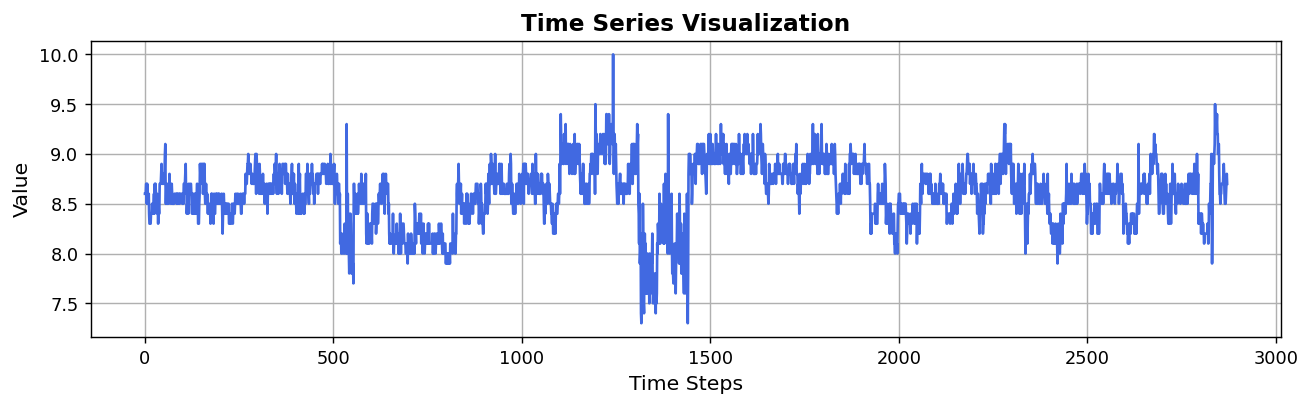

In [2]:
time_series = np.load("..\docs\source\_static\spectrum.npy")
fig = plot_time_series(time_series, dpi=128)

Import the functions used to calculate the autocorrelation function and generate the Toeplitz matrix, and set the relevant hyperparameters.

In [ ]:
from scipy import signal
from scipy.linalg import toeplitz
from statsmodels.tsa.stattools import acf

# The order of Wiener filters
filter_order = 6

Begin calculating the autocorrelation function of the input time series and generating the Toeplitz matrix.

In [ ]:
# Perform a reversible normalization operation on the input sequence
# to eliminate its distribution bias.
mean, std = np.mean(time_series), np.std(time_series)
normalized_series = (time_series - mean) / std

# We set the autocorrelation hysteresis to twice the filter order
# to ensure we have sufficient autocorrelation.
acf_vals = acf(normalized_series, nlags=filter_order * 2, fft=True)

# Constructing the autocorrelation matrix
R = toeplitz(acf_vals[:filter_order])

R

array([[1.        , 0.85940068, 0.81498192, 0.80005553, 0.7764907 ,
        0.75878007],
       [0.85940068, 1.        , 0.85940068, 0.81498192, 0.80005553,
        0.7764907 ],
       [0.81498192, 0.85940068, 1.        , 0.85940068, 0.81498192,
        0.80005553],
       [0.80005553, 0.81498192, 0.85940068, 1.        , 0.85940068,
        0.81498192],
       [0.7764907 , 0.80005553, 0.81498192, 0.85940068, 1.        ,
        0.85940068],
       [0.75878007, 0.7764907 , 0.80005553, 0.81498192, 0.85940068,
        1.        ]])

Next, we will solve for the parameters of the Wiener filter based on the constructed autocorrelation matrix and use these parameters to generate new time series data.

The specific solution method is the matrix form of the Wiener-Hough equation mentioned above. However, in this notebook, we simplify it by using the Yule-Walker equation to solve for the parameters of the AR model. Generally, the modified Yule-Walker equation can be seen as a special case of the Wiener-Hough equation, suitable for parameter estimation of AR models. The specific functional form is shown below:

~~~python
def yule_walker(A: np.ndarray) -> Tuple[np.ndarray, Union[float, np.ndarray]]:
    """
    Solving the Yule-Walker equations yields the parameters of the AR model.

    The Yule-Walker equations can be expressed in matrix form as::

    r(0)*1 + r(1)*a[1] + r(2)*a[2] + ... + r(n)*a[n]       = σ²
    r(1)*1 + r(0)*a[1] + r(1)*a[2] + ... + r(n-1)*a[n]     = 0
    r(2)*1 + r(1)*a[1] + r(0)*a[2] + ... + r(n-2)*a[n]     = 0
    ...
    r(n-1)*1 + r(n-2)*a[1] + r(n-3)*a[2] + ... + r(1)*a[n] = 0
    r(n)*1 + r(n-1)*a[1] + r(n-2)*a[2] + ... + r(0)*a[n]   = 0

    Where r(k) is the value of the autocorrelation function at lag k,
    a[i] are the coefficients of the AR model, and σ² is the variance of the noise.

    This equation can be derived based on the orthogonality principle,
    representing the relationship between the parameters of the AR model and the autocorrelation function of the sequence.

    :param A: The matrix representing the Yule-Walker equations, where the first row corresponds to the equation for σ² and the subsequent rows correspond to the equations for a1~an.

    :return: A tuple containing the vector of AR coefficients (a1~an) and the variance of the noise (σ²).
    """
    # Check if A is a ndarray and has the correct shape
    if not isinstance(A, np.ndarray):
        raise ValueError("Input A must be a numpy array.")
    if A.shape[0] < 2 or A.shape[1] < 2:
        raise ValueError(
            "Input A must have at least 2 rows and 2 columns to solve for a1~an and σ²."
        )

    # Check if the matrix A is square
    if A.shape[0] != A.shape[1]:
        raise ValueError("Input A must be a square matrix.")

    # Solve for the coefficients using the equations from the second line onwards.
    B = A[1:, 1:]  # Extracting the coefficient matrix
    c = -A[1:, 0]  # Extract the constant term and take its negative.

    try:
        # Solve for a1~an
        a = np.linalg.solve(B, c)

    except np.linalg.LinAlgError as e:
        print(f"Solution failed: {e}")
        print(
            "Reason: Matrix B is not invertible, and therefore cannot uniquely determine a1~an."
        )

        # If B is not invertible, we can use least squares to find an approximate solution.
        a = np.linalg.lstsq(B, c, rcond=None)[0]

    # Solve for σ² using the first line of the equations
    x = np.hstack([1, a])  # Construct the x vector
    sigma_sq = np.dot(A[0], x)

    return x, sigma_sq
~~~

In [5]:
# The filter coefficients and noise variance are obtained by solving the Yule-Walker equation.
coeffs, sigma_sq = yule_walker(A=R)

print("Filter Coefficients:", coeffs)
print("Noise Variance:", sigma_sq)

Filter Coefficients: [ 1.         -0.51275858 -0.12763791 -0.15651827 -0.05807143 -0.0810442 ]
Noise Variance: 0.22350238217534202


Based on the obtained $\sigma^2$, we reinitialize the white noise and generate the time series using an anti-causal whitening filter $1 / \left [ h \right ]$.

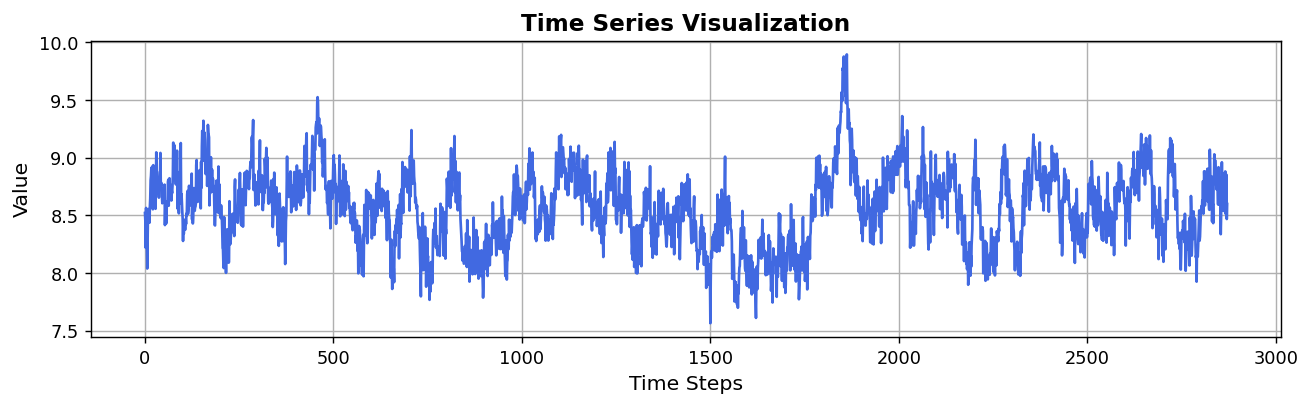

In [ ]:
# Initialize white noise
white_noise = np.random.normal(
    loc=0, scale=np.sqrt(sigma_sq), size=len(time_series) + filter_order
)

# Generating time series using an anti-causal whitening filter $1 / \left [ h \right ]$
# This is actually a convolution operation
generated_series = signal.lfilter(a=coeffs, b=1.0, x=white_noise)[filter_order:]

# The generated time series is inversely normalized
# to restore its original distribution characteristics.
generated_series = generated_series * std + mean

# Plot the generated time series
fig = plot_time_series(generated_series, dpi=128)

We further compared the autocorrelation functions of the original and output sequences to verify whether the generated time series has similar statistical properties to the original sequence.

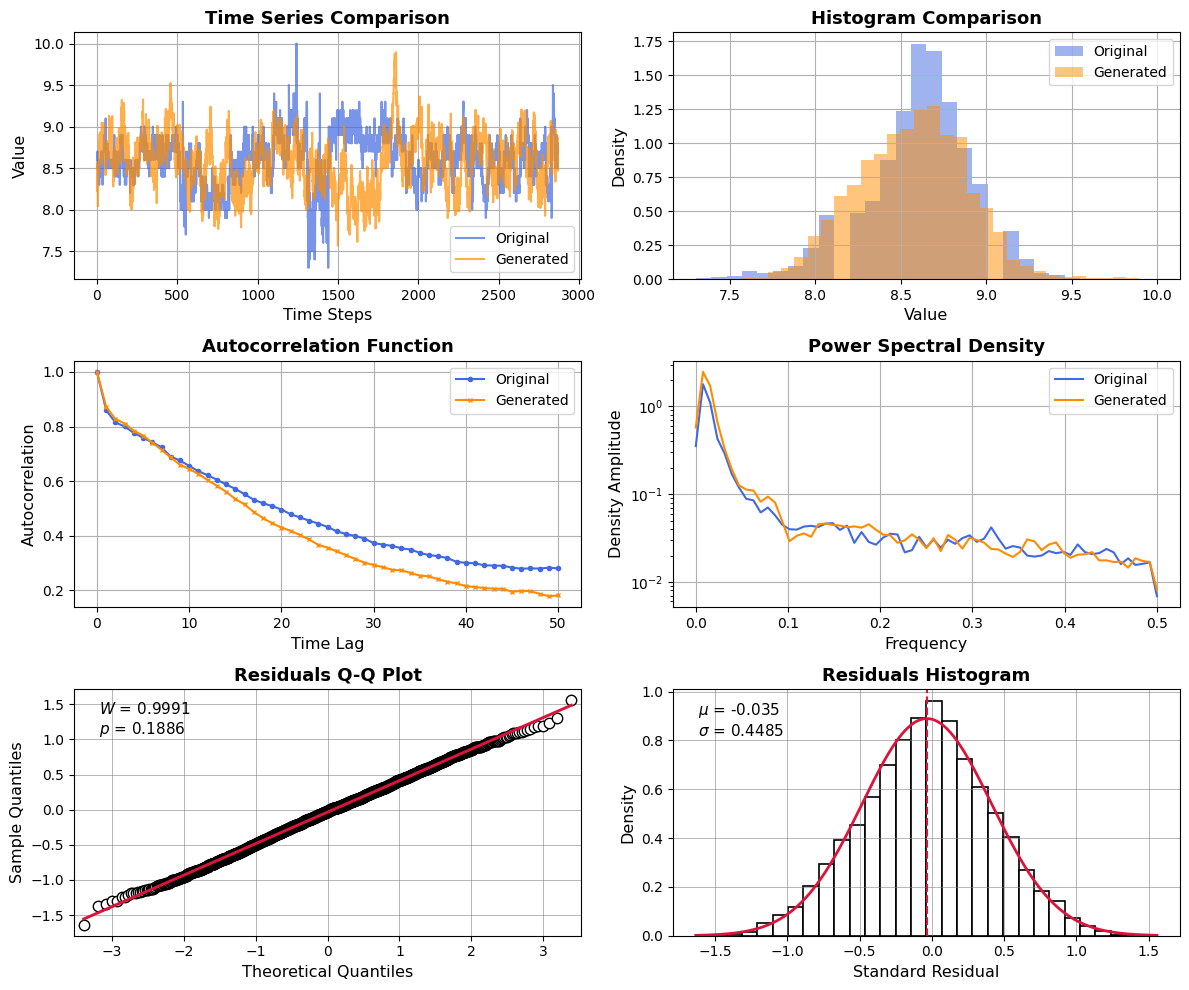

In [7]:
fig = plot_simulator_statistics(
    time_series, generated_series, residuals=generated_series - time_series
)

It can be observed from the above results that the input sequence and the generated sequence exhibit considerable similarity in autocorrelation. Moreover, their fitted power spectral densities are almost overlapping. This demonstrates that the whitening-based time series generation method using the Wiener filter can effectively capture the statistical characteristics of the input data and generate time series data with similar autocorrelation and power spectral density. This approach has broad application prospects in signal processing and time series analysis.

According to the residual test results shown in the Q-Q plot and the histogram, the residuals fitted by this procedure are approximately normally distributed. This further verifies that the generated time series data has high statistical similarity to the input data.

Below, we will further demonstrate how to use the Wiener filter-based time series generator in `S2Generator`.

Generated Series Shape: (5, 2872)


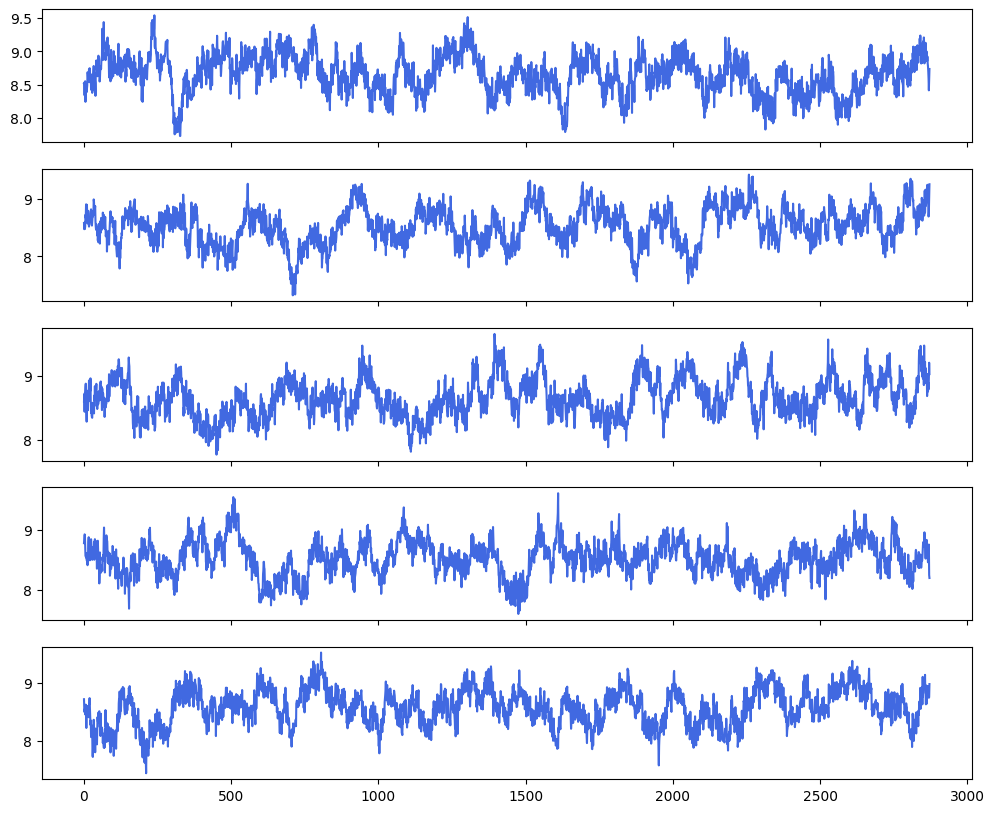

In [ ]:
# Instantiate Wiener filter simulator
# Here we chose a slightly higher-order filter to capture more of the autocorrelation characteristics.
simulator = WienerFilterSimulator(filter_order=8)

# Fitting Model
simulator.fit(time_series)

# Generate new time series data using the fitted model
generated_series = simulator.transform(
    num_samples=5, seq_len=len(time_series), random_state=128
)
print("Generated Series Shape:", generated_series.shape)

fig, ax = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
for i, series in enumerate(generated_series):
    ax[i].plot(series, color="royalblue")

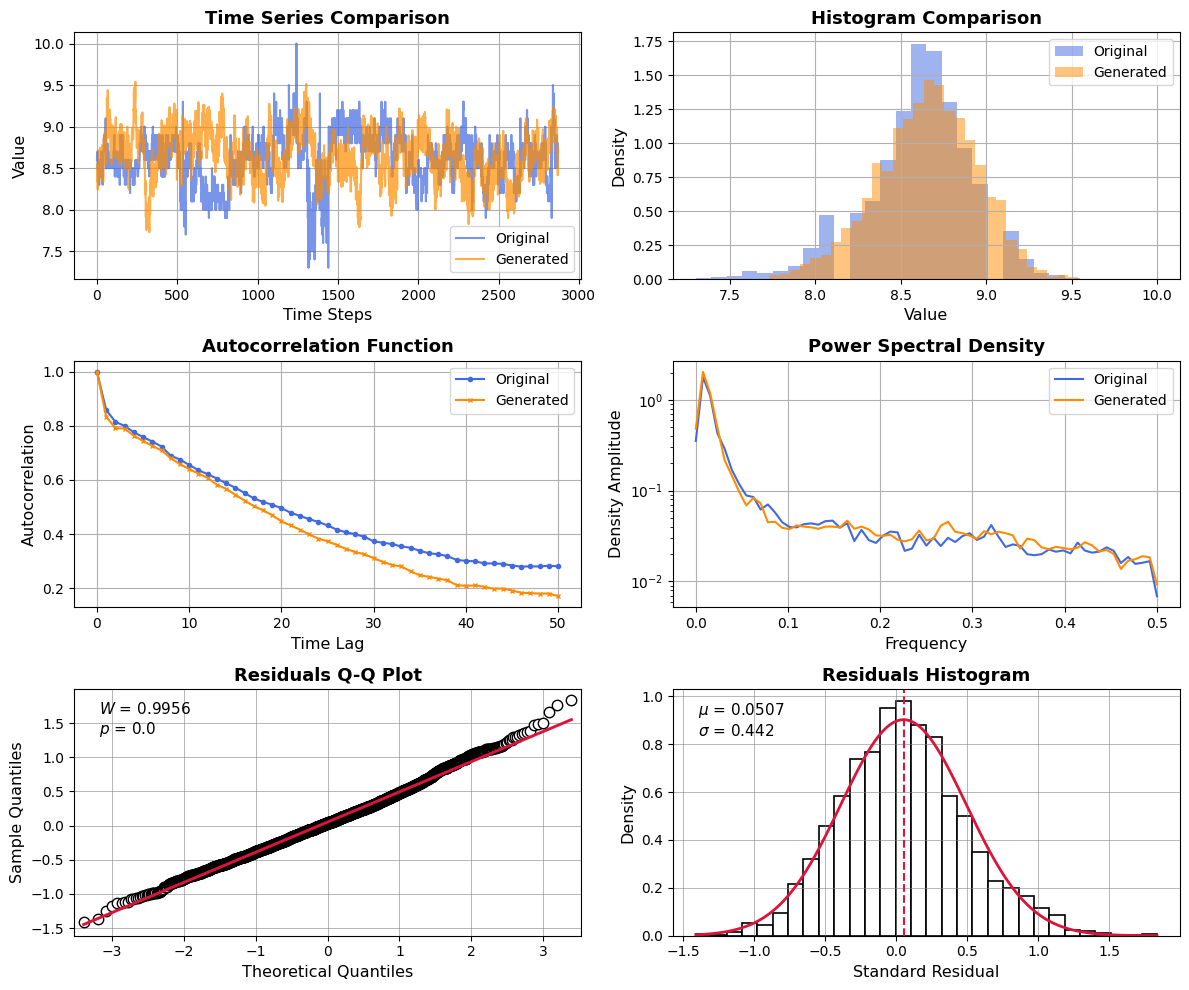

In [10]:
fig = plot_simulator_statistics(
    time_series, generated_series[0], residuals=generated_series[0] - time_series
)